### Improved Euler Method

The **Improved Euler Method** (also called Heun's Method) refines the basic Euler method by averaging the slope at the beginning and (predicted) end of each step:
$$
k_1 = f(x_n, y_n), \qquad k_2 = f(x_n + h,\, y_n + h k_1)
$$
$$
y_{n+1} = y_n + \frac{h}{2}(k_1 + k_2)
$$

This predictor-corrector approach achieves **second-order accuracy** (\\(O(h^2)\\) local error), giving substantially better results than the standard Euler method for the same step size.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def f(x, y):
    return y - x**2 + 1

def y_exact(x):
    return (x + 1)**2 - 0.5 * np.exp(x)


In [3]:
def improved_euler_table(f, x0, y0, h, n_steps):
    print(f"{'n':>2} {'x':>10} {'y':>12} {'y_exact':>12} {'error':>12}")
    print("-" * 55)

    xs, ys = [x0], [y0]
    x, y = x0, y0

    print(f"{0:2d} {x:10.6f} {y:12.6f} {y_exact(x):12.6f} {abs(y - y_exact(x)):12.6e}")

    for n in range(1, n_steps + 1):
        k1 = f(x, y)
        k2 = f(x + h, y + h * k1)
        y = y + (h / 2) * (k1 + k2)
        x = x + h
        xs.append(x)
        ys.append(y)
        print(f"{n:2d} {x:10.6f} {y:12.6f} {y_exact(x):12.6f} {abs(y - y_exact(x)):12.6e}")

    return np.array(xs), np.array(ys)


In [4]:
x0, y0 = 0, 0.5
h = 0.2
n_steps = 10

xs, ys = improved_euler_table(f, x0, y0, h, n_steps)
print(f"\ny({xs[-1]:.2f}) approx = {ys[-1]:.6f}, exact = {y_exact(xs[-1]):.6f}")


 n          x            y      y_exact        error
-------------------------------------------------------
 0   0.000000     0.500000     0.500000 0.000000e+00
 1   0.200000     0.826000     0.829299 3.298621e-03
 2   0.400000     1.206920     1.214088 7.167651e-03
 3   0.600000     1.637242     1.648941 1.169820e-02
 4   0.800000     2.110236     2.127230 1.699381e-02
 5   1.000000     2.617688     2.640859 2.317150e-02
 6   1.200000     3.149579     3.179942 3.036268e-02
 7   1.400000     3.693686     3.732400 3.871381e-02
 8   1.600000     4.235097     4.283484 4.838662e-02
 9   1.800000     4.755619     4.815176 5.955772e-02
10   2.000000     5.233055     5.305472 7.241732e-02

y(2.00) approx = 5.233055, exact = 5.305472


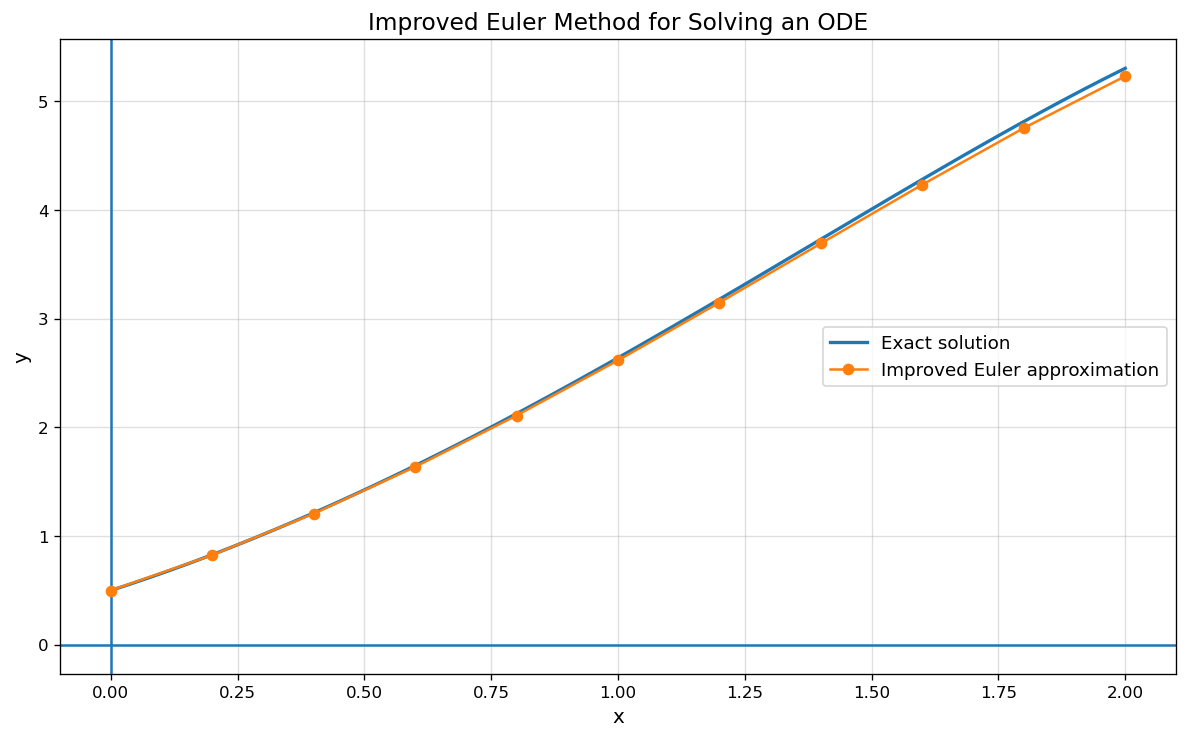

In [5]:
plt.figure(figsize=(12, 7), dpi=120)

# Axes lines (Desmos-style)
plt.axhline(0)
plt.axvline(0)

x_fine = np.linspace(x0, xs[-1], 500)
y_fine = y_exact(x_fine)

plt.plot(x_fine, y_fine, linewidth=2, label="Exact solution")
plt.plot(xs, ys, 'o-', markersize=6, label="Improved Euler approximation")

plt.grid(True, alpha=0.4)
plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.title("Improved Euler Method for Solving an ODE", fontsize=14)

plt.legend(fontsize=11)
plt.show()
